In [85]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
import time

In [86]:
load_dotenv()

True

In [87]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=1.2,
    top_p=0.95,
)

c:\Users\p\Documents\Coding\Agentic-AI-with-LangGraph\learning_langgraph\Lib\site-packages\pydantic\main.py:263: UserWarning: WARNING! top_p is not default parameter.
                    top_p was transferred to model_kwargs.
                    Please confirm that top_p is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


In [88]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [89]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [90]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [91]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [92]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!',
 'explanation': 'A delicious joke! Let\'s break it down.\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a new and unexpected way. Typically, when someone says they\'re feeling "crusty," it means they\'re feeling irritable, grumpy, or a bit short-tempered.\n\nIn this joke, the phrase is applied to a pizza, which is a clever connection because a pizza has a crust - the outer layer of the bread. So, the punchline "it was feeling a little crusty" is a wordplay that references both the pizza\'s physical crust and the emotional state of being grumpy.\n\nThe humor comes from the unexpected twist on the usual meaning of "crusty" and the clever connection to the pizza\'s characteristics. It\'s a lighthearted and cheesy (pun intended) joke that brings a smile to your face!'}

In [93]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!', 'explanation': 'A delicious joke! Let\'s break it down.\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a new and unexpected way. Typically, when someone says they\'re feeling "crusty," it means they\'re feeling irritable, grumpy, or a bit short-tempered.\n\nIn this joke, the phrase is applied to a pizza, which is a clever connection because a pizza has a crust - the outer layer of the bread. So, the punchline "it was feeling a little crusty" is a wordplay that references both the pizza\'s physical crust and the emotional state of being grumpy.\n\nThe humor comes from the unexpected twist on the usual meaning of "crusty" and the clever connection to the pizza\'s characteristics. It\'s a lighthearted and cheesy (pun intended) joke that brings a smile to your face!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoi

In [94]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!', 'explanation': 'A delicious joke! Let\'s break it down.\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a new and unexpected way. Typically, when someone says they\'re feeling "crusty," it means they\'re feeling irritable, grumpy, or a bit short-tempered.\n\nIn this joke, the phrase is applied to a pizza, which is a clever connection because a pizza has a crust - the outer layer of the bread. So, the punchline "it was feeling a little crusty" is a wordplay that references both the pizza\'s physical crust and the emotional state of being grumpy.\n\nThe humor comes from the unexpected twist on the usual meaning of "crusty" and the clever connection to the pizza\'s characteristics. It\'s a lighthearted and cheesy (pun intended) joke that brings a smile to your face!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpo

In [95]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a lifelong commitment!',
 'explanation': 'A clever play on words. This joke is humorous because it takes the common phrase "tangled up in a lifelong commitment" (which typically refers to the complexities and responsibilities that come with marriage) and gives it a literal twist. Spaghetti, being a long, slender, and flexible type of pasta, can easily become tangled or knotted.\n\nIn this joke, the spaghetti\'s fear of getting "tangled up" is a clever pun that references both the physical properties of spaghetti and the idea of being entangled in a romantic relationship. The humor comes from the unexpected connection between the physical characteristics of spaghetti and the emotional complexities of marriage.\n\nThe joke relies on a lighthearted and whimsical personification of spaghetti, attributing human-like emotions and concerns to an inanimate object. This ty

In [96]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a lifelong commitment!', 'explanation': 'A clever play on words. This joke is humorous because it takes the common phrase "tangled up in a lifelong commitment" (which typically refers to the complexities and responsibilities that come with marriage) and gives it a literal twist. Spaghetti, being a long, slender, and flexible type of pasta, can easily become tangled or knotted.\n\nIn this joke, the spaghetti\'s fear of getting "tangled up" is a clever pun that references both the physical properties of spaghetti and the idea of being entangled in a romantic relationship. The humor comes from the unexpected connection between the physical characteristics of spaghetti and the emotional complexities of marriage.\n\nThe joke relies on a lighthearted and whimsical personification of spaghetti, attributing human-like emotions and concerns to an inani

## Time Travel

In [100]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f18f476-9363-61ca-8000-5fe102dce0b9"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f18f476-9363-61ca-8000-5fe102dce0b9'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-03T14:27:09.580504+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18f476-934f-6403-bfff-d04b2c05d768'}}, tasks=(PregelTask(id='bf82e706-55a7-bf26-c4ee-3d6b128a4d4a', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!'}),), interrupts=())

In [101]:
workflow.invoke(None, config={"configurable": {"thread_id": "1", "checkpoint_id": "1f18f476-9363-61ca-8000-5fe102dce0b9"}})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty! (get it?)',
 'explanation': 'A classic play on words. This joke is an example of a pun, which is a type of wordplay that uses multiple meanings of a word to create humor.\n\nIn this case, the joke starts by asking why the pizza is in a bad mood, setting up the expectation that the answer will be a typical reason why someone or something might be feeling down. But instead, the punchline "it was feeling a little crusty" uses a clever twist on words.\n\nThe word "crusty" has a double meaning here. In one sense, "crusty" refers to the outer layer of a pizza, which is typically crispy and golden brown. But "crusty" can also be used to describe someone\'s mood or personality, implying that they are irritable, grumpy, or a bit rough around the edges.\n\nThe joke relies on this double meaning to create a unexpected connection between the setup and the punchline. By using the word "crusty" i

In [102]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty! (get it?)', 'explanation': 'A classic play on words. This joke is an example of a pun, which is a type of wordplay that uses multiple meanings of a word to create humor.\n\nIn this case, the joke starts by asking why the pizza is in a bad mood, setting up the expectation that the answer will be a typical reason why someone or something might be feeling down. But instead, the punchline "it was feeling a little crusty" uses a clever twist on words.\n\nThe word "crusty" has a double meaning here. In one sense, "crusty" refers to the outer layer of a pizza, which is typically crispy and golden brown. But "crusty" can also be used to describe someone\'s mood or personality, implying that they are irritable, grumpy, or a bit rough around the edges.\n\nThe joke relies on this double meaning to create a unexpected connection between the setup and the punchline. By using

### Updating State

In [103]:
workflow.update_state({"configurable":{"thread_id": "1", "checkpoint_id": "1f18f476-9363-61ca-8000-5fe102dce0b9", "checkpoint_ns": ""}}, {"topic": "Samosa"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18f479-9ec8-6908-8001-2bc42157ef5b'}}

In [104]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18f479-9ec8-6908-8001-2bc42157ef5b'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-03T14:28:31.306086+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18f476-9363-61ca-8000-5fe102dce0b9'}}, tasks=(PregelTask(id='0a5226e4-f57a-c52c-9670-e087658d0873', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty! (get it?)', 'explanation': 'A classic play on words. This joke is an example of a pun, which is a type of wordplay that uses multiple meanings of a word to create humor.\n\nIn this case, the joke starts by asking why the pizza is in a bad mood, setting u

In [105]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f18f479-9ec8-6908-8001-2bc42157ef5b"}})

{'topic': 'Samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crunchy" on the outside and "empty" on the inside!',
 'explanation': 'A deliciously clever joke. Here\'s a breakdown of why it\'s funny:\n\nThe joke relies on a play on words, using the characteristics of a samosa (a popular Indian snack) to make a humorous connection to human emotions. \n\n1. "Crunchy" on the outside: Samosas are known for their crispy, crunchy exterior, which is a desirable texture. However, in this joke, "crunchy" is used to describe the samosa\'s emotional state. In human psychology, being "hard" or "tough" on the outside can be a facade that hides inner struggles. So, the samosa is "crunchy" on the outside, implying it\'s putting up a tough exterior.\n\n2. "Empty" on the inside: Samosas are typically filled with savory ingredients like spiced potatoes, peas, and onions. If a samosa is "empty" on the inside, it means it\'s lacking its usual filling. In this joke, the

In [106]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crunchy" on the outside and "empty" on the inside!', 'explanation': 'A deliciously clever joke. Here\'s a breakdown of why it\'s funny:\n\nThe joke relies on a play on words, using the characteristics of a samosa (a popular Indian snack) to make a humorous connection to human emotions. \n\n1. "Crunchy" on the outside: Samosas are known for their crispy, crunchy exterior, which is a desirable texture. However, in this joke, "crunchy" is used to describe the samosa\'s emotional state. In human psychology, being "hard" or "tough" on the outside can be a facade that hides inner struggles. So, the samosa is "crunchy" on the outside, implying it\'s putting up a tough exterior.\n\n2. "Empty" on the inside: Samosas are typically filled with savory ingredients like spiced potatoes, peas, and onions. If a samosa is "empty" on the inside, it means it\'s lacking its usual fillin

## Fault Tolerance

In [107]:
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [108]:
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(30)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"step3": 'done'}

In [109]:
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

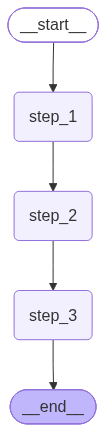

In [110]:
graph

In [115]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [116]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18f47e-7cec-6bc7-8006-d6885c608d45'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-08-03T14:30:41.973519+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18f47e-7ce8-6144-8005-638eb260fd0b'}}, tasks=(PregelTask(id='0b6db74e-b47c-d5ef-1687-f82e4b8da502', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18f47e-7ce8-6144-8005-638eb260fd0b'}}, metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-08-03T14:30:41.971606+00:0

In [117]:
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [118]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18f481-4fce-6ee2-8008-ef75b66965c1'}}, metadata={'source': 'loop', 'step': 8, 'parents': {}}, created_at='2026-08-03T14:31:57.773364+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18f481-4fcb-6c44-8007-38d261e415d3'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18f481-4fcb-6c44-8007-38d261e415d3'}}, metadata={'source': 'loop', 'step': 7, 'parents': {}}, created_at='2026-08-03T14:31:57.772067+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18f47e-7cec-6bc7-8006-d6885c608d45'}}, tasks=(PregelTask(id='7